# 1. 提案手法とDiffSCM・ベースラインの評価結果の表へのまとめ

## 1.1 各日時の結果をデータフレームにまとめる

In [1]:
import os

os.chdir("/home/hashikami/projects/Diff")

In [3]:
import pandas as pd


def merge_one_day_results(oneday_results_dir):
    # 指定されたディレクトリ内のすべてのファイルの中で、ファイル名が"effectiveness_do"で始まるファイルを取得
    files = [f for f in os.listdir(oneday_results_dir) if f.startswith("effectiveness_do")]
    
    # ディレクトリ内のすべてのファイルをデータフレーム形式で読み込んで、それらを結合して一つのデータフレームにする
    dfs = []
    for file in files:
        df = pd.read_csv(os.path.join(oneday_results_dir, file))
        dfs.append(df)
        
    return pd.concat(dfs)

In [12]:
# 試しに実行

base_dir = "results/evaluate_counterfactual/effectiveness/"
day = "2025-12-10_13"
oneday_results_dir = os.path.join(base_dir, day)
results_12_10 = merge_one_day_results(oneday_results_dir)
results_12_10.head()

,do_parent,attribute,mean,std
0,thickness,thickness,0.047,0.011
1,thickness,intensity,3.820,1.440
2,thickness,slant,1.746,0.296
3,thickness,width,2.295,0.156
0,intensity,thickness,0.163,0.027


## 1.2 複数の日時の結果を一つのデータフレームに結合

In [4]:
base_dir = "results/evaluate_counterfactual/effectiveness/"
days = ['2025-12-10_13', '2025-12-11_13']

result_day_dict = {}
for day in days:
    oneday_results_dir = os.path.join(base_dir, day)
    day_results = merge_one_day_results(oneday_results_dir)
    result_day_dict[day] = day_results

In [6]:
def merge_days_results(method_day_dict, result_day_dict):
    
    # pandasデータフレームにmethod, guidance scaleのカラムを新しく追加して保存
    
    dfs = []
    for day, config in config_day_dict.items():
        df = result_day_dict[day]
        df['method'] = config['method']
        df['guidance scale'] = config['guidance scale']
        dfs.append(df)
        
    return pd.concat(dfs)
    
    

In [7]:
config_day_dict = {
    "2025-12-10_13": {"method": "ours(graph is given)", "guidance scale": 1.0},
    "2025-12-11_13": {"method": "diffscm", "guidance scale": 1.0},
}

df = merge_days_results(config_day_dict, result_day_dict)
df.head()

,do_parent,attribute,mean,std,method,guidance scale
0,thickness,thickness,0.047,0.011,ours(graph is given),1.0
1,thickness,intensity,3.820,1.440,ours(graph is given),1.0
2,thickness,slant,1.746,0.296,ours(graph is given),1.0
3,thickness,width,2.295,0.156,ours(graph is given),1.0
0,intensity,thickness,0.163,0.027,ours(graph is given),1.0


## 1.3 結果を棒グラフとして可視化して比較

In [13]:
df.columns

Index(['do_parent', ' attribute', ' mean', ' std', 'method', 'guidance scale'], dtype='object')

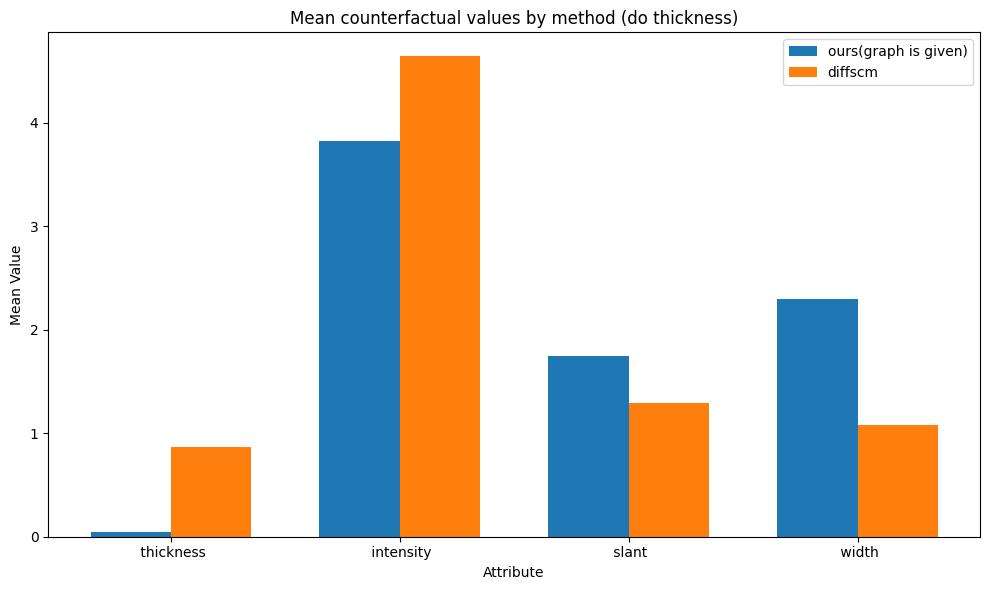

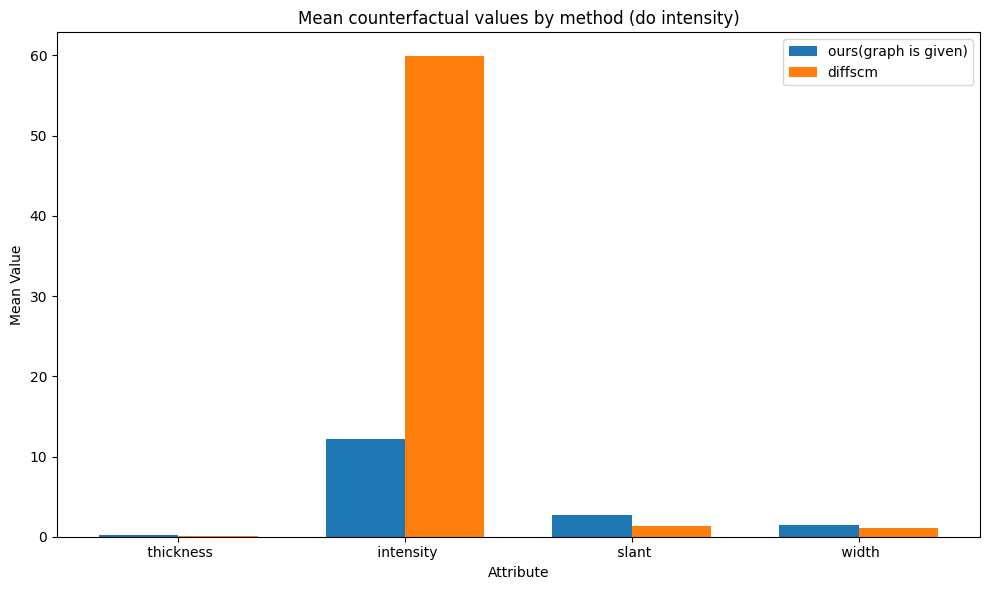

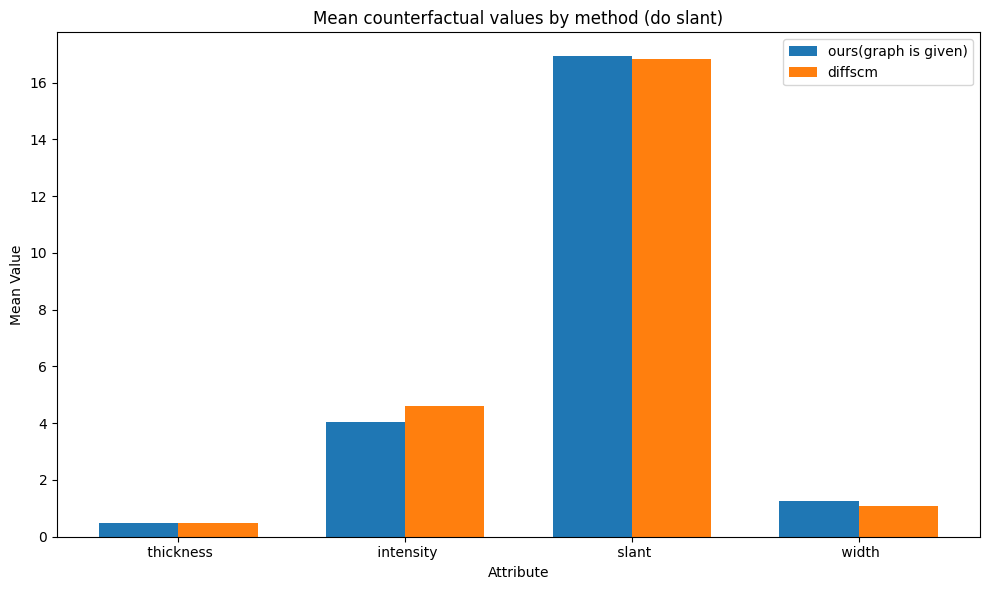

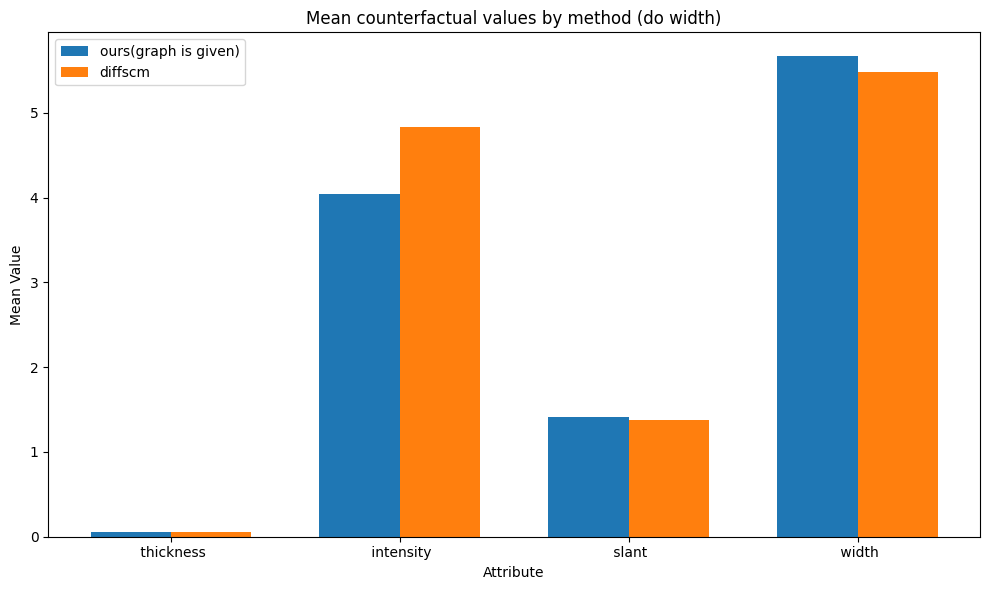

In [16]:
import matplotlib.pyplot as plt

# methodカラムに含まれるユニークな手法名のみ抽出
methods = df['method'].unique()

attributes = df[' attribute'].unique()
do_parents = df['do_parent'].unique()

# 可視化: do_parentごとに mean を methodごとに色分け棒グラフ
for do_parent in do_parents:
    plt.figure(figsize=(10, 6))
    subset = df[df['do_parent'] == do_parent]
    x = range(len(attributes))
    bar_width = 0.35

    for i, method in enumerate(methods):
        method_subset = subset[subset['method'] == method]
        # attributeの順番を揃える
        means = [method_subset[method_subset[' attribute'] == attr][' mean'].values[0] if not method_subset[method_subset[' attribute'] == attr].empty else 0 for attr in attributes]
        plt.bar([pos + i * bar_width for pos in x], means, width=bar_width, label=method)

    plt.xticks([pos + bar_width / 2 for pos in x], attributes)  # attributeごとにラベル
    plt.xlabel('Attribute')
    plt.ylabel('Mean Value')
    plt.title(f'Mean counterfactual values by method (do {do_parent})')
    plt.legend()
    plt.tight_layout()
    plt.show()
